## 1) Imports and Reproducible Setup

This cell imports the ODT generator, DLGN-SF model, and training utility from the package.
It also sets high-level experiment settings to match Paper 1's synthetic setup:
- depth = 4
- d = 100
- n = 40000
- beta = 10

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from first_experiment.odt import generate_cob_odt_data
from first_experiment.dlgn import DLGNSF
from first_experiment.training import TrainConfig, train_dlgn_sf, evaluate_dlgn_sf
import copy

# Paper-1-style synthetic setting
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
SEED = 3410

# DLGN-SF architecture from milestone plan
HIDDEN_DIMS = [16]*5  # L=4, M=20
BETA = 11.0

## 2) Generate COB-ODT Data

This cell creates one synthetic dataset from a depth-4 COB-ODT with 30000 points.

In [8]:
x, y, tree, meta = generate_cob_odt_data(
    num_data=2*N_TRAIN,
    dim=DIM,
    depth=DEPTH,
    seed=SEED,
    threshold=0.0,
)

x_train = x[:N_TRAIN]
y_train = y[:N_TRAIN]
x_eval = x[N_TRAIN:]
y_eval = y[N_TRAIN:]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("meta:", meta)
print("label counts:", dict(zip(*np.unique(y_train, return_counts=True))))

x_train shape: (80000, 100)
y_train shape: (80000,)
meta: {'num_requested': 160000, 'num_kept': 160000, 'num_pruned': 0, 'dim': 100, 'depth': 5, 'num_internal_nodes': 31, 'num_leaf_nodes': 32, 'threshold': 0.0, 'seed': 3410}
label counts: {np.int8(-1): np.int64(39776), np.int8(1): np.int64(40224)}


## 3) Build DLGN-SF and Capture Initial Gating Vectors

This cell initializes the model and extracts initial effective gating vectors V^l
(before training). These are the vectors we compare to ODT hyperplane normals.

In [27]:
model = DLGNSF(
    input_dim=DIM,
    hidden_dims=HIDDEN_DIMS,
    beta=BETA,
    bias=False,
    value_input_mode="ones",  # default in current code
    gating_weight_scale=0.5,
    value_weight_scale=1.0,
)

init_gating = model.effective_gating_weights()  # list of tensors, one per hidden layer
print("num hidden layers:", len(init_gating))
print("layer shapes:", [tuple(w.shape) for w in init_gating])

num hidden layers: 5
layer shapes: [(16, 100), (16, 100), (16, 100), (16, 100), (16, 100)]


## 4) Train DLGN-SF on the Synthetic Data

This cell trains the model using Adam + BCE-with-logits via train_dlgn_sf.
You can increase epochs if needed for stronger clustering.

In [26]:
epochs = 2000 # increase to 500+ if you want stronger effect
train_cfg = TrainConfig(
    epochs=epochs,          
    lr=0.001,
    batch_size=N_TRAIN//500,
    seed=SEED,
    device="cpu",        # switch to "cuda" if available and desired
    snapshot_epochs=tuple(range(0, epochs+1, 20)), # +1 to include last epoch
    show_progress=True,
    weight_decay_gating=0.0,
    weight_decay_value=0.0,
)

out = train_dlgn_sf(
    model=model,
    x_train=x_train,
    y_train=y_train,
    config=train_cfg,
)

final_model = out["model"]
epoch_losses = out["epoch_losses"]
final_gating = final_model.effective_gating_weights()

print("epochs logged:", len(epoch_losses))
print("initial loss:", epoch_losses[0], "final loss:", epoch_losses[-1])

Training DLGN-SF:   0%|          | 0/2001 [00:00<?, ?it/s]

KeyboardInterrupt: 

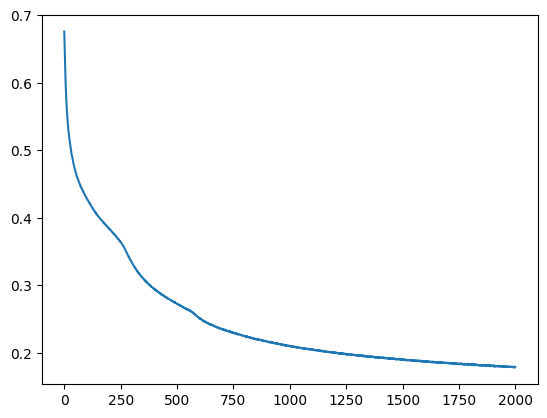

In [24]:
plt.plot(epoch_losses)

## Metrics at each snapshot epoch (train vs test)

Uses `out["checkpoint_snapshots"]` from `train_dlgn_sf` (full model weights per snapshot).
Expects `x_train`, `y_train`, `x_eval`, `y_eval` in `{-1,+1}`, and `out`, `train_cfg` (or set `DEVICE` manually).
Log loss is the same BCE-with-logits as training; error is `zero_one_loss` from `evaluate_dlgn_sf`.

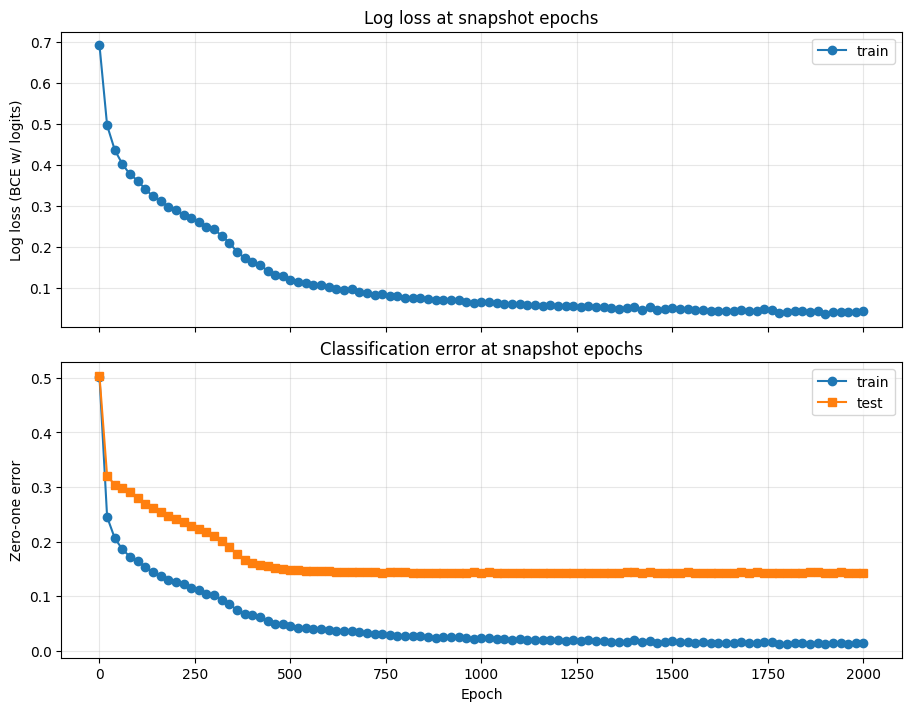

In [20]:

# --- adjust names if yours differ ---
checkpoint_snapshots = out["checkpoint_snapshots"]
DEVICE = train_cfg.device  # e.g. "cpu" or "cuda"

eval_model = copy.deepcopy(out["model"]).to(DEVICE)

epochs_sorted = sorted(checkpoint_snapshots.keys())

train_log_loss = []
test_log_loss = []
train_err = []
test_err = []

for ep in epochs_sorted:
    eval_model.load_state_dict(checkpoint_snapshots[ep])
    eval_model.to(DEVICE)

    m_tr = evaluate_dlgn_sf(
        model=eval_model, x_eval=x_train, y_eval=y_train, device=DEVICE
    )
    m_te = evaluate_dlgn_sf(
        model=eval_model, x_eval=x_eval, y_eval=y_eval, device=DEVICE
    )

    train_log_loss.append(m_tr["log_loss"])
    test_log_loss.append(m_te["log_loss"])
    train_err.append(m_tr["zero_one_loss"])
    test_err.append(m_te["zero_one_loss"])

epochs_sorted = np.asarray(epochs_sorted)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)

axes[0].plot(epochs_sorted, train_log_loss, marker="o", label="train")
# axes[0].plot(epochs_sorted, test_log_loss, marker="s", label="test")
axes[0].set_ylabel("Log loss (BCE w/ logits)")
axes[0].set_title("Log loss at snapshot epochs")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_sorted, train_err, marker="o", label="train")
axes[1].plot(epochs_sorted, test_err, marker="s", label="test")
axes[1].set_ylabel("Zero-one error")
axes[1].set_xlabel("Epoch")
axes[1].set_title("Classification error at snapshot epochs")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

## 5) Helper Functions for Clustering Metrics

This cell defines small helpers:
- stack all gating vectors across layers,
- compute max cosine alignment to ODT normals,
- compute sign-invariant distance to hyperplane normals.

In [11]:
def stack_gating_vectors(gating_list):
    # gating_list: list of tensors, each shape (M, d)
    arrs = [w.detach().cpu().numpy() for w in gating_list]
    return np.concatenate(arrs, axis=0)  # shape: (L*M, d)

def max_abs_cosine_to_odt(gating_vectors, odt_normals):
    # returns vector of shape (num_gating_vectors,)
    g = gating_vectors / np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u = odt_normals / np.linalg.norm(odt_normals, axis=1, keepdims=True)
    cos_mat = np.abs(g @ u.T)  # sign-invariant
    return np.max(cos_mat, axis=1)

def min_sign_invariant_distance(gating_vectors, odt_normals):
    # distance between normalized vectors with sign invariance: min(||v-u||, ||v+u||)
    g = gating_vectors / np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u = odt_normals / np.linalg.norm(odt_normals, axis=1, keepdims=True)
    d1 = np.linalg.norm(g[:, None, :] - u[None, :, :], axis=2)
    d2 = np.linalg.norm(g[:, None, :] + u[None, :, :], axis=2)
    return np.min(np.minimum(d1, d2), axis=1)

# ODT internal-node normals
odt_normals = tree.w_list  # shape: (2^DEPTH - 1, DIM)

g_init = stack_gating_vectors(init_gating)
g_final = stack_gating_vectors(final_gating)

print("all gating vectors shape:", g_init.shape, "(expected L*M x d)")
print("ODT normals shape:", odt_normals.shape)

all gating vectors shape: (80, 100) (expected L*M x d)
ODT normals shape: (31, 100)


## Scatter at a chosen training epoch (from checkpoint snapshots)

Set `EPOCH` to an integer that was included in `TrainConfig(snapshot_epochs=...)`.
If that epoch is missing from `out["checkpoint_snapshots"]`, re-run training with that epoch listed in `snapshot_epochs`.
Gating vectors are recovered with `effective_gating_weights_from_checkpoint`.

/var/folders/pd/w8bnb5rs76g9lp6n7cpjt8ch0000gn/T/ipykernel_68329/3779677367.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_odt_nodes)


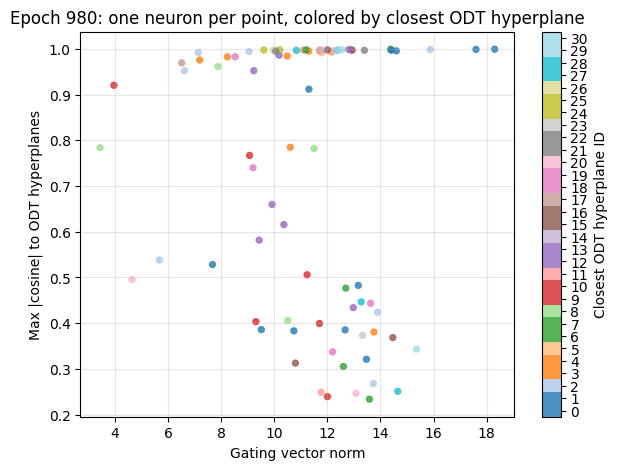

In [14]:

# ---- user argument ----
EPOCH = 980   # change this

# ---- expected variables from earlier cells ----
# out = train_dlgn_sf(...)
# tree = COB-ODT tree used for data
from first_experiment.training import effective_gating_weights_from_checkpoint

checkpoint_snapshots = out["checkpoint_snapshots"]
odt_normals = tree.w_list

if EPOCH not in checkpoint_snapshots:
    raise KeyError(
        f"No snapshot for epoch {EPOCH}. Available: {sorted(checkpoint_snapshots.keys())}"
    )

def stack_gating_numpy(gating_list):
    return np.concatenate([np.asarray(w) for w in gating_list], axis=0)

def neuron_alignment_stats(gating_vectors, odt_normals):
    g_norm = np.linalg.norm(gating_vectors, axis=1, keepdims=True)
    u_norm = np.linalg.norm(odt_normals, axis=1, keepdims=True)
    g_norm = np.maximum(g_norm, 1e-12)
    u_norm = np.maximum(u_norm, 1e-12)

    g_unit = gating_vectors / g_norm
    u_unit = odt_normals / u_norm

    cos_abs = np.abs(g_unit @ u_unit.T)
    closest_id = np.argmax(cos_abs, axis=1)
    max_cos = cos_abs[np.arange(cos_abs.shape[0]), closest_id]
    norms = g_norm.squeeze(1)
    return norms, max_cos, closest_id

g_epoch = stack_gating_numpy(
    effective_gating_weights_from_checkpoint(out["model"], checkpoint_snapshots[EPOCH])
)
norms, maxcos, closest = neuron_alignment_stats(g_epoch, odt_normals)

num_odt_nodes = odt_normals.shape[0]
cmap = plt.cm.get_cmap("tab20", num_odt_nodes)

plt.figure(figsize=(7, 5))
sc = plt.scatter(
    norms,
    maxcos,
    c=closest,
    cmap=cmap,
    s=28,
    alpha=0.8,
    edgecolors="none",
)

plt.xlabel("Gating vector norm")
plt.ylabel("Max |cosine| to ODT hyperplanes")
plt.title(f"Epoch {EPOCH}: one neuron per point, colored by closest ODT hyperplane")
plt.grid(alpha=0.3)

cbar = plt.colorbar(sc, ticks=np.arange(num_odt_nodes))
cbar.set_label("Closest ODT hyperplane ID")
plt.clim(-0.5, num_odt_nodes - 0.5)

plt.show()